In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../outputs/clustering_ready_dataset.csv")

df.head()

,Temperature,Humidity,Wind_Speed,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Hour,Day_of_Week,Month,Is_Weekend,Is_Peak_Hour,Zone_1_lag_1,Zone_2_lag_1,Zone_3_lag_1,Zone_1_roll_mean_24h,Zone_2_roll_mean_24h,Zone_3_roll_mean_24h
0,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434,0,6,1,1,0,34055.69620,16128.87538,20240.96386,34055.696200,16128.875380,20240.963860
1,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373,0,6,1,1,0,29814.68354,19375.07599,20131.08434,31935.189870,17751.975685,20186.024100
2,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711,0,6,1,1,0,29128.10127,19006.68693,19668.43373,30999.493670,18170.212767,20013.493977
3,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964,0,6,1,1,0,28228.86076,18361.09422,18899.27711,30306.835442,18217.933130,19734.939760
4,5.853,76.9,0.081,26624.81013,17416.41337,18130.12048,0,6,1,1,0,27335.69620,17872.34043,18442.40964,29712.607594,18148.814590,19476.433736


In [3]:
df.shape

(52415, 17)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52415 entries, 0 to 52414
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               52415 non-null  float64
 1   Humidity                  52415 non-null  float64
 2   Wind_Speed                52415 non-null  float64
 3   Zone_1_Power_Consumption  52415 non-null  float64
 4   Zone_2_Power_Consumption  52415 non-null  float64
 5   Zone_3_Power_Consumption  52415 non-null  float64
 6   Hour                      52415 non-null  int64  
 7   Day_of_Week               52415 non-null  int64  
 8   Month                     52415 non-null  int64  
 9   Is_Weekend                52415 non-null  int64  
 10  Is_Peak_Hour              52415 non-null  int64  
 11  Zone_1_lag_1              52415 non-null  float64
 12  Zone_2_lag_1              52415 non-null  float64
 13  Zone_3_lag_1              52415 non-null  float64
 14  Zone_1_roll_mean_

In [5]:
X = df.copy()

In [6]:
X.head()

,Temperature,Humidity,Wind_Speed,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Hour,Day_of_Week,Month,Is_Weekend,Is_Peak_Hour,Zone_1_lag_1,Zone_2_lag_1,Zone_3_lag_1,Zone_1_roll_mean_24h,Zone_2_roll_mean_24h,Zone_3_roll_mean_24h
0,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434,0,6,1,1,0,34055.69620,16128.87538,20240.96386,34055.696200,16128.875380,20240.963860
1,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373,0,6,1,1,0,29814.68354,19375.07599,20131.08434,31935.189870,17751.975685,20186.024100
2,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711,0,6,1,1,0,29128.10127,19006.68693,19668.43373,30999.493670,18170.212767,20013.493977
3,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964,0,6,1,1,0,28228.86076,18361.09422,18899.27711,30306.835442,18217.933130,19734.939760
4,5.853,76.9,0.081,26624.81013,17416.41337,18130.12048,0,6,1,1,0,27335.69620,17872.34043,18442.40964,29712.607594,18148.814590,19476.433736


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
X_scaled.shape

(52415, 17)

In [10]:
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [11]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

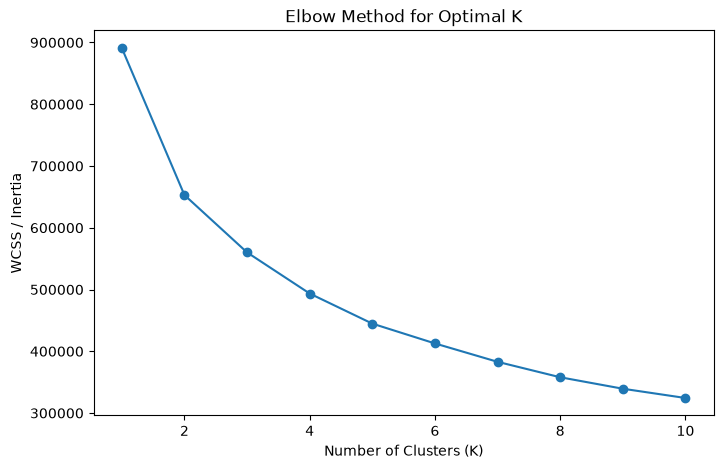

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [13]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

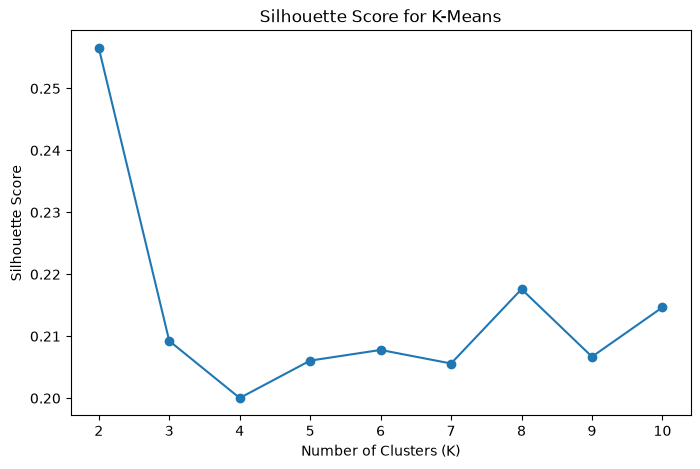

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")

plt.show()

In [15]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [16]:
clusters[:10]

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

In [17]:
df["Cluster"] = clusters

In [18]:
df.head()

,Temperature,Humidity,Wind_Speed,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Hour,Day_of_Week,Month,Is_Weekend,Is_Peak_Hour,Zone_1_lag_1,Zone_2_lag_1,Zone_3_lag_1,Zone_1_roll_mean_24h,Zone_2_roll_mean_24h,Zone_3_roll_mean_24h,Cluster
0,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434,0,6,1,1,0,34055.69620,16128.87538,20240.96386,34055.696200,16128.875380,20240.963860,3
1,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373,0,6,1,1,0,29814.68354,19375.07599,20131.08434,31935.189870,17751.975685,20186.024100,3
2,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711,0,6,1,1,0,29128.10127,19006.68693,19668.43373,30999.493670,18170.212767,20013.493977,3
3,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964,0,6,1,1,0,28228.86076,18361.09422,18899.27711,30306.835442,18217.933130,19734.939760,3
4,5.853,76.9,0.081,26624.81013,17416.41337,18130.12048,0,6,1,1,0,27335.69620,17872.34043,18442.40964,29712.607594,18148.814590,19476.433736,3


In [19]:
df["Cluster"].value_counts().sort_index()

Cluster
0     8013
1     7637
2    18584
3    18181
Name: count, dtype: int64

In [20]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,Temperature,Humidity,Wind_Speed,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Hour,Day_of_Week,Month,Is_Weekend,Is_Peak_Hour,Zone_1_lag_1,Zone_2_lag_1,Zone_3_lag_1,Zone_1_roll_mean_24h,Zone_2_roll_mean_24h,Zone_3_roll_mean_24h
Cluster,,,,,,,,,,,,,,,,,
0,26.784953,59.036489,4.504648,37747.266336,25486.509919,27295.849322,12.135280,3.045301,7.358792,0.287034,0.172470,37766.614640,25498.718902,27294.038526,36343.568711,24544.885658,26156.304050
1,17.923347,69.113241,1.410034,41796.165017,26878.312512,22776.511052,19.707477,2.969883,6.332068,0.278513,0.930994,41692.943884,26826.718077,22657.028078,31706.315986,20444.057139,16208.297034
2,19.178090,63.520761,1.504367,33569.613655,21818.566423,16221.248973,14.474010,2.902174,6.407878,0.263721,0.012968,33597.828492,21832.987102,16204.717399,31652.803758,20369.119200,16079.937831
3,15.292096,76.809311,1.533863,24742.096904,15839.434306,12957.347225,4.733128,3.092514,6.318189,0.310599,0.000165,24748.401463,15840.549529,13025.611877,31534.045029,20393.847340,16377.186947


In [21]:
df.groupby("Cluster")["Is_Peak_Hour"].mean()

Cluster
0    0.172470
1    0.930994
2    0.012968
3    0.000165
Name: Is_Peak_Hour, dtype: float64

In [22]:
df.groupby("Cluster")["Hour"].mean()

Cluster
0    12.135280
1    19.707477
2    14.474010
3     4.733128
Name: Hour, dtype: float64

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [24]:
X_pca.shape

(52415, 2)

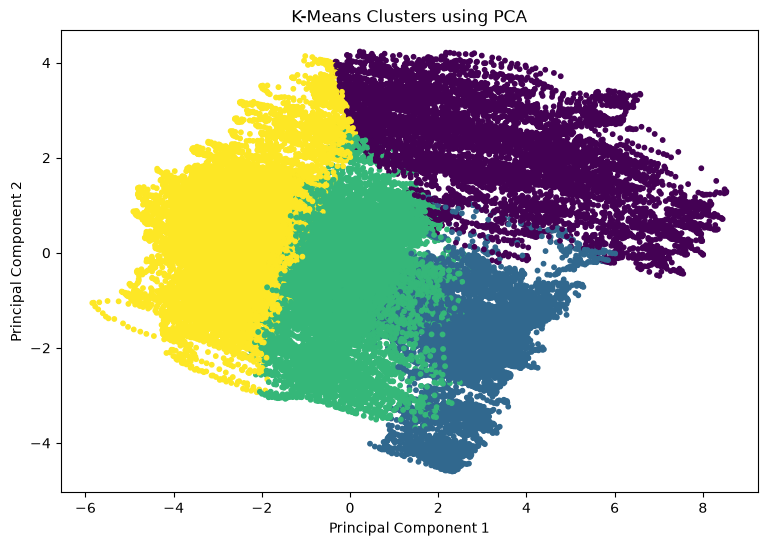

In [25]:
plt.figure(figsize=(9,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters using PCA")

plt.show()

In [26]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

In [27]:
np.unique(dbscan_labels)

array([  -1,    0,    1, ..., 1182, 1183, 1184], shape=(1186,))

In [28]:
for eps in [0.3, 0.5, 0.7, 1.0]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = dbscan.fit_predict(X_scaled)

    print(eps, np.unique(labels))

0.3 [  -1    0    1 ... 1015 1016 1017]
0.5 [  -1    0    1 ... 1182 1183 1184]
0.7 [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 224

In [29]:
joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

['../models/kmeans_model.pkl']

In [30]:
df.to_csv(
    "../outputs/energy_cluster_results.csv",
    index=False
)